In [13]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
# 0-Preset: Load file

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

TARGET = 'Current_Price_USD'   # target variable for prediction

df = pd.read_csv('apple_products_pricing_2020_2026.csv', parse_dates=['Date'])
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns | {df['Date'].min():%Y-%m-%d} to {df['Date'].max():%Y-%m-%d}")
df.head(5)

Loaded 80,000 rows x 14 columns | 2020-09-19 to 2026-07-31


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35


In [ ]:
# 0-Preset: cleaning - drop leakage / redundant columns

LEAK_COLS = ['Current_Price_INR', 'Launch_Price_INR', 'Discount_Pct']

# Evidence before dropping
print(f"corr(Current_Price_USD, Current_Price_INR)  = {df[TARGET].corr(df['Current_Price_INR']):.4f}  -> target in INR (leakage)")
recon = (1 - df[TARGET] / df['Launch_Price_USD']) * 100
print(f"Discount_Pct vs (1 - Current/Launch)*100    : max abs diff = {(recon - df['Discount_Pct']).abs().max():.4f}  -> derived from target (leakage)")
print(f"corr(Launch_Price_USD, Launch_Price_INR)    = {df['Launch_Price_USD'].corr(df['Launch_Price_INR']):.4f}  -> redundant")

df = df.drop(columns=LEAK_COLS)
print(f"\nDropped {LEAK_COLS}")
print(f"Remaining columns: {list(df.columns)}")

corr(Current_Price_USD, Current_Price_INR)  = 0.9951  -> target in INR (leakage)
Discount_Pct vs (1 - Current/Launch)*100    : max abs diff = 0.0514  -> derived from target (leakage)
corr(Launch_Price_USD, Launch_Price_INR)    = 1.0000  -> redundant

Dropped ['Current_Price_INR', 'Launch_Price_INR', 'Discount_Pct']
Remaining columns: ['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition', 'Launch_Price_USD', 'Current_Price_USD', 'Sale_Event', 'Stock_Status', 'Rating', 'Reviews_Count']


In [ ]:
# 1-Feature Engineering: Add the launch date based on manual research

# Launch date: researched (ground truth) vs proxy (first listing date)
researched_launch_date = {
    'Apple Watch Series 6 (44mm)': '2020-09-18',
    'iPad Air (4th Gen) 64GB': '2020-10-23',
    'iPhone 12 64GB': '2020-10-23',
    'iPhone 12 Pro 128GB': '2020-10-23',
    'MacBook Air M1 256GB': '2020-11-17',
    'iPad Pro 11-inch (M1) 128GB': '2021-05-21',
    'iPhone 13 128GB': '2021-09-24',
    'iPhone 13 Pro Max 256GB': '2021-09-24',
    'iPad (9th Gen) 64GB': '2021-09-24',
    'Apple Watch Series 7 (45mm)': '2021-10-15',
    'MacBook Pro 14-inch M1 Pro 512GB': '2021-10-26',
    'iPad Air (5th Gen) 64GB': '2022-03-18',
    'MacBook Air M2 256GB': '2022-07-15',
    'Apple Watch Series 8 (45mm)': '2022-09-16',
    'iPhone 14 128GB': '2022-09-16',
    'iPhone 14 Pro 128GB': '2022-09-16',
    'Apple Watch Ultra': '2022-09-23',
    'iPad Pro 12.9-inch (M2) 256GB': '2022-10-26',
    'MacBook Pro 14-inch M2 Pro 512GB': '2023-01-24',
    'Apple Watch Series 9 (45mm)': '2023-09-22',
    'Apple Watch Ultra 2': '2023-09-22',
    'iPhone 15 128GB': '2023-09-22',
    'iPhone 15 Pro Max 256GB': '2023-09-22',
    'MacBook Pro 14-inch M3 Pro 512GB': '2023-11-07',
    'MacBook Air M3 256GB': '2024-03-08',
    'iPad Pro 11-inch (M4) 256GB': '2024-05-15',
    'iPhone 16 128GB': '2024-09-20',
    'iPhone 16 Pro 256GB': '2024-09-20',
    'Apple Watch Series X (45mm)': '2024-09-20',
    'MacBook Pro 14-inch M4 Pro 512GB': '2024-11-08',
    'iPhone 17 128GB': '2025-09-19',
}
df['researched_launch_date'] = pd.to_datetime(df['Model_Name'].map(researched_launch_date))
unmapped = df['researched_launch_date'].isna().sum()
if unmapped:
    print(f"WARNING: {unmapped:,} rows have a Model_Name not in researched_launch_date — proxy will be used instead.")

proxy_launch_date = df.groupby('Model_Name')['Date'].transform('min')

launch_date_compare = (
    df.assign(proxy_launch_date=proxy_launch_date)[['Model_Name', 'researched_launch_date', 'proxy_launch_date']]
      .drop_duplicates('Model_Name')
      .sort_values('researched_launch_date')
      .reset_index(drop=True)
)
launch_date_compare['diff_days'] = (launch_date_compare['proxy_launch_date']
                                     - launch_date_compare['researched_launch_date']).dt.days

print(f"Proxy vs researched launch date — {len(launch_date_compare)} models:")
print(launch_date_compare.to_string(index=False))
print(f"\nmax |diff| = {launch_date_compare['diff_days'].abs().max()} days, "
      f"mean |diff| = {launch_date_compare['diff_days'].abs().mean():.2f} days")

major = launch_date_compare[launch_date_compare['diff_days'].abs() > 7]
if len(major):
    print(f"\n{len(major)} model(s) with a major difference (>7 days) between proxy and researched date:")
    print(major.to_string(index=False))
else:
    print("\nNo model shows a major difference (>7 days) — the proxy (first listing date) is a")
    print("reliable stand-in for the true launch date across the board.")

# Depreciation clock uses the researched date where available, falling back to the proxy
launch_date = df['researched_launch_date'].fillna(proxy_launch_date)
df['days_since_launch'] = (df['Date'] - launch_date).dt.days
df = df.drop(columns=['researched_launch_date'])

# Sale_Event: NaN means "no event" -> make it an explicit category before deriving features
n_nan = df['Sale_Event'].isna().sum()
df['Sale_Event'] = df['Sale_Event'].fillna('None')
print(f"\nSale_Event: {n_nan:,} NaN rows ({n_nan/len(df)*100:.1f}%) interpreted as 'no event' and filled with 'None'")

df['month'] = df['Date'].dt.month
df['is_sale_event'] = df['Sale_Event'].ne('None').astype(int)


# Observation: proxy_launch_date is a reliable stand-in for the true launch date across the board, 
# with no model showing a major difference (>7 days) between proxy and researched date. 

Proxy vs researched launch date — 31 models:
                      Model_Name researched_launch_date proxy_launch_date  diff_days
     Apple Watch Series 6 (44mm)             2020-09-18        2020-09-19          1
         iPad Air (4th Gen) 64GB             2020-10-23        2020-10-23          0
                  iPhone 12 64GB             2020-10-23        2020-10-23          0
             iPhone 12 Pro 128GB             2020-10-23        2020-10-23          0
            MacBook Air M1 256GB             2020-11-17        2020-11-17          0
     iPad Pro 11-inch (M1) 128GB             2021-05-21        2021-05-22          1
                 iPhone 13 128GB             2021-09-24        2021-09-24          0
         iPhone 13 Pro Max 256GB             2021-09-24        2021-09-24          0
             iPad (9th Gen) 64GB             2021-09-24        2021-09-25          1
     Apple Watch Series 7 (45mm)             2021-10-15        2021-10-15          0
MacBook Pro 14-inch 

In [ ]:
# 1-Feature Engineering: Parse the model name to extract model type, variant tier, storage (GB) and generation

# Model_Name-agnostic parsed attributes
mn = df['Model_Name'].astype(str)
gb = mn.str.extract(r'(\d+)\s*GB', expand=False).astype(float)
tb = mn.str.extract(r'(\d+)\s*TB', expand=False).astype(float) * 1024
df['storage_gb'] = gb.fillna(tb)

TIERS = ['Pro Max', 'Ultra', 'Pro', 'Plus', 'Max', 'Air', 'mini', 'SE']  # order matters: match most specific first
def parse_tier(name):
    for t in TIERS:
        if t in name:
            return t
    return 'base'
df['variant_tier'] = mn.map(parse_tier)

# generation: model number (iPhone 15, Series 6) -> ordinal "(9th Gen)" -> Apple-silicon chip (M1/M2/...)
gen_named   = mn.str.extract(r'(?:iPhone|Series|AirPods)\s+(\d+)', expand=False)
gen_ordinal = mn.str.extract(r'\((\d+)(?:st|nd|rd|th)\s+Gen\)', expand=False)
gen_chip    = mn.str.extract(r'\bM(\d+)\b', expand=False)
df['generation'] = gen_named.fillna(gen_ordinal).fillna(gen_chip).astype(float)

print("\nParsed attributes per unique model (heuristic — verify any NaNs are acceptable):")
df[['Model_Name', 'Product_Category', 'variant_tier', 'storage_gb', 'generation']].drop_duplicates('Model_Name').reset_index(drop=True)



Parsed attributes per unique model (heuristic — verify any NaNs are acceptable):


,Model_Name,Product_Category,variant_tier,storage_gb,generation
0,Apple Watch Series 6 (44mm),Watch,base,NaN,6.0
1,iPad Air (4th Gen) 64GB,iPad,Air,64.0,4.0
2,iPhone 12 64GB,iPhone,base,64.0,12.0
3,iPhone 12 Pro 128GB,iPhone,Pro,128.0,12.0
4,MacBook Air M1 256GB,Mac,Air,256.0,1.0
5,iPad Pro 11-inch (M1) 128GB,iPad,Pro,128.0,1.0
6,iPhone 13 128GB,iPhone,base,128.0,13.0
7,iPhone 13 Pro Max 256GB,iPhone,Pro Max,256.0,13.0
8,iPad (9th Gen) 64GB,iPad,base,64.0,9.0
9,Apple Watch Series 7 (45mm),Watch,base,NaN,7.0


In [7]:
#2-EDA: Dataset overview 

overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null_%': (df.notna().mean() * 100).round(2),
    'n_unique': df.nunique(),
    'example': df.iloc[0].astype(str),
})
overview

,dtype,non_null_%,n_unique,example
Date,datetime64[us],100.00,2130,2020-09-19 00:00:00
Platform,str,100.00,2,Flipkart
Product_Category,str,100.00,4,Watch
Model_Name,str,100.00,31,Apple Watch Series 6 (44mm)
Condition,str,100.00,2,New
Launch_Price_USD,int64,100.00,9,429
Current_Price_USD,float64,100.00,49611,435.81
Sale_Event,str,100.00,5,None
Stock_Status,str,100.00,3,In Stock
Rating,float64,100.00,12,4.7


In [8]:
#2-EDA: Dataset completeness audit

# Group columns by shared missingness rate; explain which row subsets drive it
null_rate = (100 - df.notna().mean() * 100).round(2)
print("Columns grouped by % missing:")
for rate, cols in null_rate.groupby(null_rate).groups.items():
    print(f"  {rate:>6.2f}% missing -> {list(cols)}")

incomplete = null_rate[null_rate > 0].index.tolist()
if incomplete:
    for col in incomplete:
        seg = df[df[col].isna()]
        print(f"\nRows missing '{col}' — breakdown by Product_Category:")
        print(seg['Product_Category'].value_counts().to_string())
    print("\nNote: NaNs in parsed attributes (storage_gb / generation) are expected where the model name")
    print("carries no such token (e.g., MacBooks have no GB suffix); impute or flag before modeling.")
else:
    print("\nNo missing values in any column.")

Columns grouped by % missing:
    0.00% missing -> ['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition', 'Launch_Price_USD', 'Current_Price_USD', 'Sale_Event', 'Stock_Status', 'Rating', 'Reviews_Count', 'days_since_launch', 'month', 'is_sale_event', 'variant_tier']
    9.45% missing -> ['generation']
   22.33% missing -> ['storage_gb']

Rows missing 'storage_gb' — breakdown by Product_Category:
Product_Category
Watch    17865

Rows missing 'generation' — breakdown by Product_Category:
Product_Category
Watch    7557

Note: NaNs in parsed attributes (storage_gb / generation) are expected where the model name
carries no such token (e.g., MacBooks have no GB suffix); impute or flag before modeling.


In [10]:
#2-EDA: Mapping model names to launch prices

launch_prices = sorted(df['Launch_Price_USD'].drop_duplicates().tolist())

model_launch_map = (
    df[['Model_Name', 'Launch_Price_USD']]
      .drop_duplicates()
      .sort_values(['Launch_Price_USD', 'Model_Name'])
)
ordered_models = model_launch_map['Model_Name'].tolist()

launch_price_pivot = (
    df.pivot_table(
        index='Model_Name',
        columns='Launch_Price_USD',
        values='Current_Price_USD',
        aggfunc='count',
        fill_value=0
    )
    .reindex(index=ordered_models, columns=launch_prices, fill_value=0)
)
launch_price_pivot


Launch_Price_USD,329,429,599,799,849,999,1099,1199,1999
Model_Name,,,,,,,,,
iPad (9th Gen) 64GB,2573,0,0,0,0,0,0,0,0
Apple Watch Series 6 (44mm),0,2572,0,0,0,0,0,0,0
Apple Watch Series 7 (45mm),0,2600,0,0,0,0,0,0,0
Apple Watch Series 8 (45mm),0,2606,0,0,0,0,0,0,0
Apple Watch Series 9 (45mm),0,2530,0,0,0,0,0,0,0
Apple Watch Series X (45mm),0,2520,0,0,0,0,0,0,0
iPad Air (4th Gen) 64GB,0,0,2677,0,0,0,0,0,0
iPad Air (5th Gen) 64GB,0,0,2583,0,0,0,0,0,0
Apple Watch Ultra,0,0,0,2544,0,0,0,0,0


In [11]:
#3-Target Profiling: Current Price USD

t = df[TARGET].dropna()

prof = pd.DataFrame({TARGET: t.describe()}).T
prof['skew'] = [t.skew()]
prof['kurtosis'] = [t.kurt()]

q1, q3 = t.quantile([.25, .75]); iqr = q3 - q1
out = (t < q1 - 1.5 * iqr) | (t > q3 + 1.5 * iqr)
print(f"{TARGET}: skew {t.skew():.2f} — right-skewed raw prices (log-transform territory)")
print(f"{TARGET} IQR outliers: {out.sum():,} rows ({out.mean()*100:.2f}%)")
above = (df[TARGET] > df['Launch_Price_USD']).mean() * 100
print(f"Rows selling ABOVE launch price: {above:.2f}% — scarcity premiums / price fluctuation")
prof.round(3)

Current_Price_USD: skew 1.11 — right-skewed raw prices (log-transform territory)
Current_Price_USD IQR outliers: 5,076 rows (6.35%)
Rows selling ABOVE launch price: 11.12% — scarcity premiums / price fluctuation


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Current_Price_USD,80000.0,782.77,461.674,109.93,432.93,699.74,989.112,2038.97,1.11,0.704


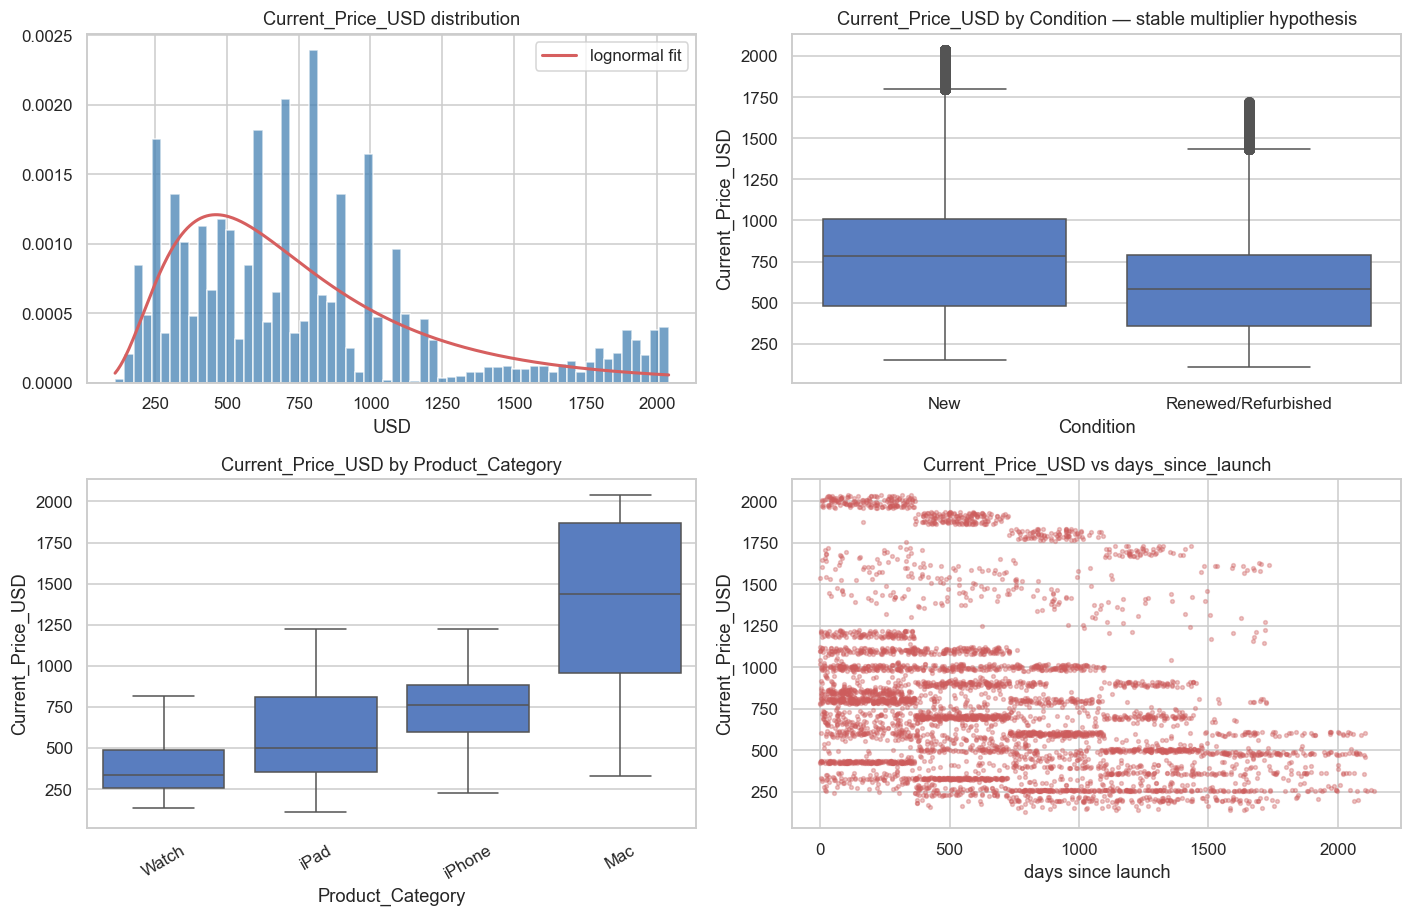

In [14]:
#3-Target Profiling: EDA on Current Price USD

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

ax = axes[0, 0]
ax.hist(t, bins=60, density=True, alpha=.75, color='steelblue', edgecolor='white')
shape, loc, scale = stats.lognorm.fit(t, floc=0)
xs = np.linspace(t.min(), t.max(), 400)
ax.plot(xs, stats.lognorm.pdf(xs, shape, loc, scale), 'r-', lw=2, label='lognormal fit')
ax.set(title=f'{TARGET} distribution', xlabel='USD')
ax.legend()

sns.boxplot(data=df, x='Condition', y=TARGET, ax=axes[0, 1])
axes[0, 1].set_title(f'{TARGET} by Condition — stable multiplier hypothesis')

sns.boxplot(data=df, x='Product_Category', y=TARGET, ax=axes[1, 0])
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].set_title(f'{TARGET} by Product_Category')

sample = df.sample(min(5000, len(df)), random_state=0)
axes[1, 1].scatter(sample['days_since_launch'], sample[TARGET], s=6, alpha=.35, color='indianred')
axes[1, 1].set(title=f'{TARGET} vs days_since_launch', xlabel='days since launch', ylabel=TARGET)

plt.tight_layout()
plt.show()

In [ ]:
# 4-Feature Profiling: EDA on numeric features

NUM_FEATS = ['Launch_Price_USD', 'Rating', 'Reviews_Count', 'storage_gb', 'generation',
             'days_since_launch', 'month', 'is_sale_event']
num_summary = df[NUM_FEATS].describe().T
num_summary['skew'] = df[NUM_FEATS].skew()
num_summary['distribution_flag'] = np.where(num_summary['skew'].abs() > 1, 'skewed / heavy-tailed', 'ok')
num_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,distribution_flag
Launch_Price_USD,80000.0,963.96,470.09,329.0,599.0,799.0,1199.0,1999.0,1.03,skewed / heavy-tailed
Rating,80000.0,4.45,0.27,3.8,4.3,4.4,4.7,4.9,-0.30,ok
Reviews_Count,80000.0,2406.00,1973.63,10.0,896.0,1893.5,3383.0,11526.0,1.25,skewed / heavy-tailed
storage_gb,62135.0,223.17,146.37,64.0,128.0,128.0,256.0,512.0,0.97,ok
generation,72443.0,8.17,5.45,1.0,3.0,8.0,14.0,17.0,0.16,ok
days_since_launch,80000.0,685.65,493.94,0.0,280.0,590.0,1005.0,2142.0,0.70,ok
month,80000.0,6.40,3.46,1.0,3.0,6.0,10.0,12.0,0.07,ok
is_sale_event,80000.0,0.08,0.28,0.0,0.0,0.0,0.0,1.0,3.02,skewed / heavy-tailed


In [16]:
# 4-Feature Profiling: EDA on categorical features

CAT_FEATS = ['Platform', 'Product_Category', 'Model_Name', 'Condition', 'Sale_Event', 'Stock_Status', 'variant_tier']
cat_summary = pd.DataFrame({
    'cardinality': {c: df[c].nunique() for c in CAT_FEATS},
    'top_5_categories': {c: dict(df[c].value_counts().head(5)) for c in CAT_FEATS},
})
cat_summary

,cardinality,top_5_categories
Platform,2,"{'Flipkart': 40043, 'Amazon': 39957}"
Product_Category,4,"{'iPhone': 28589, 'Mac': 18020, 'Watch': 17865, 'iPad': 15526}"
Model_Name,31,"{'iPhone 14 Pro 128GB': 2734, 'iPad Air (4th Gen) 64GB': 2677, 'iPad Pro 11-inch (M1) 128GB': 2661, 'iPhone 17 128GB..."
Condition,2,"{'New': 59985, 'Renewed/Refurbished': 20015}"
Sale_Event,5,"{'None': 73351, 'Black Friday': 2497, 'Big Billion Days': 1579, 'Great Indian Festival': 1504, 'Prime Day': 1069}"
Stock_Status,3,"{'In Stock': 55034, 'Out of Stock': 13475, 'Low Stock': 11491}"
variant_tier,5,"{'base': 30867, 'Pro': 25937, 'Air': 13009, 'Pro Max': 5150, 'Ultra': 5037}"


In [17]:
# 4-Feature-Target Analysis: Relationship exploration

# Association with the target. Spearman for numerics; eta-squared for categoricals.
def eta_squared(frame, cat, target):
    grand = frame[target].mean()
    ss_between = frame.groupby(cat)[target].agg(['count', 'mean']).eval('count * (mean - @grand) ** 2').sum()
    ss_total = ((frame[target] - grand) ** 2).sum()
    return ss_between / ss_total

num_assoc = pd.DataFrame({
    f'spearman_vs_{TARGET}': df[NUM_FEATS + [TARGET]].corr(method='spearman')[TARGET].drop(TARGET),
}).sort_values(f'spearman_vs_{TARGET}', key=lambda s: s.abs(), ascending=False)

cat_assoc = pd.DataFrame({
    f'eta2_vs_{TARGET}': {c: eta_squared(df, c, TARGET) for c in CAT_FEATS},
}).sort_values(f'eta2_vs_{TARGET}', ascending=False)

print("Numeric features (Spearman):")
print(num_assoc.round(3).to_string())
print("\nCategorical features (eta-squared: share of target variance explained):")
print(cat_assoc.round(3).to_string())

Numeric features (Spearman):
                   spearman_vs_Current_Price_USD
Launch_Price_USD                           0.920
storage_gb                                 0.864
days_since_launch                         -0.357
Reviews_Count                             -0.316
generation                                -0.198
Rating                                     0.113
is_sale_event                             -0.094
month                                     -0.025

Categorical features (eta-squared: share of target variance explained):
                  eta2_vs_Current_Price_USD
Model_Name                            0.911
Product_Category                      0.576
variant_tier                          0.452
Condition                             0.031
Stock_Status                          0.014
Sale_Event                            0.008
Platform                              0.000


In [18]:
# 4-Feature-Target Analysis: Cardinality assessment

# How much of Model_Name's signal do the agnostic attributes recover?
df['_agnostic_combo'] = (df['Product_Category'] + '|' + df['variant_tier'] + '|'
                         + df['storage_gb'].fillna(-1).astype(int).astype(str) + '|'
                         + df['generation'].fillna(-1).astype(int).astype(str))
df['_cat_price_combo'] = df['Product_Category'] + '|' + df['Launch_Price_USD'].astype(str)

comparison = pd.DataFrame({
    'cardinality': {
        'Product_Category': df['Product_Category'].nunique(),
        'Model_Name': df['Model_Name'].nunique(),
        'agnostic combo (cat+tier+storage+gen)': df['_agnostic_combo'].nunique(),
        'Product_Category + Launch_Price_USD': df['_cat_price_combo'].nunique(),
    },
    f'eta2_vs_{TARGET}': {
        'Product_Category': eta_squared(df, 'Product_Category', TARGET),
        'Model_Name': eta_squared(df, 'Model_Name', TARGET),
        'agnostic combo (cat+tier+storage+gen)': eta_squared(df, '_agnostic_combo', TARGET),
        'Product_Category + Launch_Price_USD': eta_squared(df, '_cat_price_combo', TARGET),
    },
})
print(comparison.round(3).to_string())

recovered = comparison.loc['agnostic combo (cat+tier+storage+gen)', f'eta2_vs_{TARGET}'] / \
            max(comparison.loc['Model_Name', f'eta2_vs_{TARGET}'], 1e-9) * 100
recovered_price = comparison.loc['Product_Category + Launch_Price_USD', f'eta2_vs_{TARGET}'] / \
            max(comparison.loc['Model_Name', f'eta2_vs_{TARGET}'], 1e-9) * 100
print(f"\nAgnostic attributes recover {recovered:.1f}% of Model_Name's explanatory power on {TARGET}.")
print("If close to 100%, drop Model_Name from the feature set with little cost — and gain")
print("the ability to score unseen models. Note the combo's cardinality vs Model_Name's:")
print("a gap means some models collapse to the same attribute tuple (usually harmless).")
print(f"\nProduct_Category + Launch_Price_USD recovers {recovered_price:.1f}% of Model_Name's explanatory")
print("power with no parsing heuristics at all — compare its cardinality/eta2 tradeoff against the")
print("agnostic combo above. It cannot, however, distinguish an unseen model's storage/tier/generation")
print("if a new model reuses an existing category+launch-price pair (e.g. a same-priced refresh).")
df = df.drop(columns=['_agnostic_combo', '_cat_price_combo'])

                                       cardinality  eta2_vs_Current_Price_USD
Product_Category                                 4                      0.576
Model_Name                                      31                      0.911
agnostic combo (cat+tier+storage+gen)           30                      0.910
Product_Category + Launch_Price_USD             16                      0.905

Agnostic attributes recover 100.0% of Model_Name's explanatory power on Current_Price_USD.
If close to 100%, drop Model_Name from the feature set with little cost — and gain
the ability to score unseen models. Note the combo's cardinality vs Model_Name's:
a gap means some models collapse to the same attribute tuple (usually harmless).

Product_Category + Launch_Price_USD recovers 99.4% of Model_Name's explanatory
power with no parsing heuristics at all — compare its cardinality/eta2 tradeoff against the
agnostic combo above. It cannot, however, distinguish an unseen model's storage/tier/generation
if a

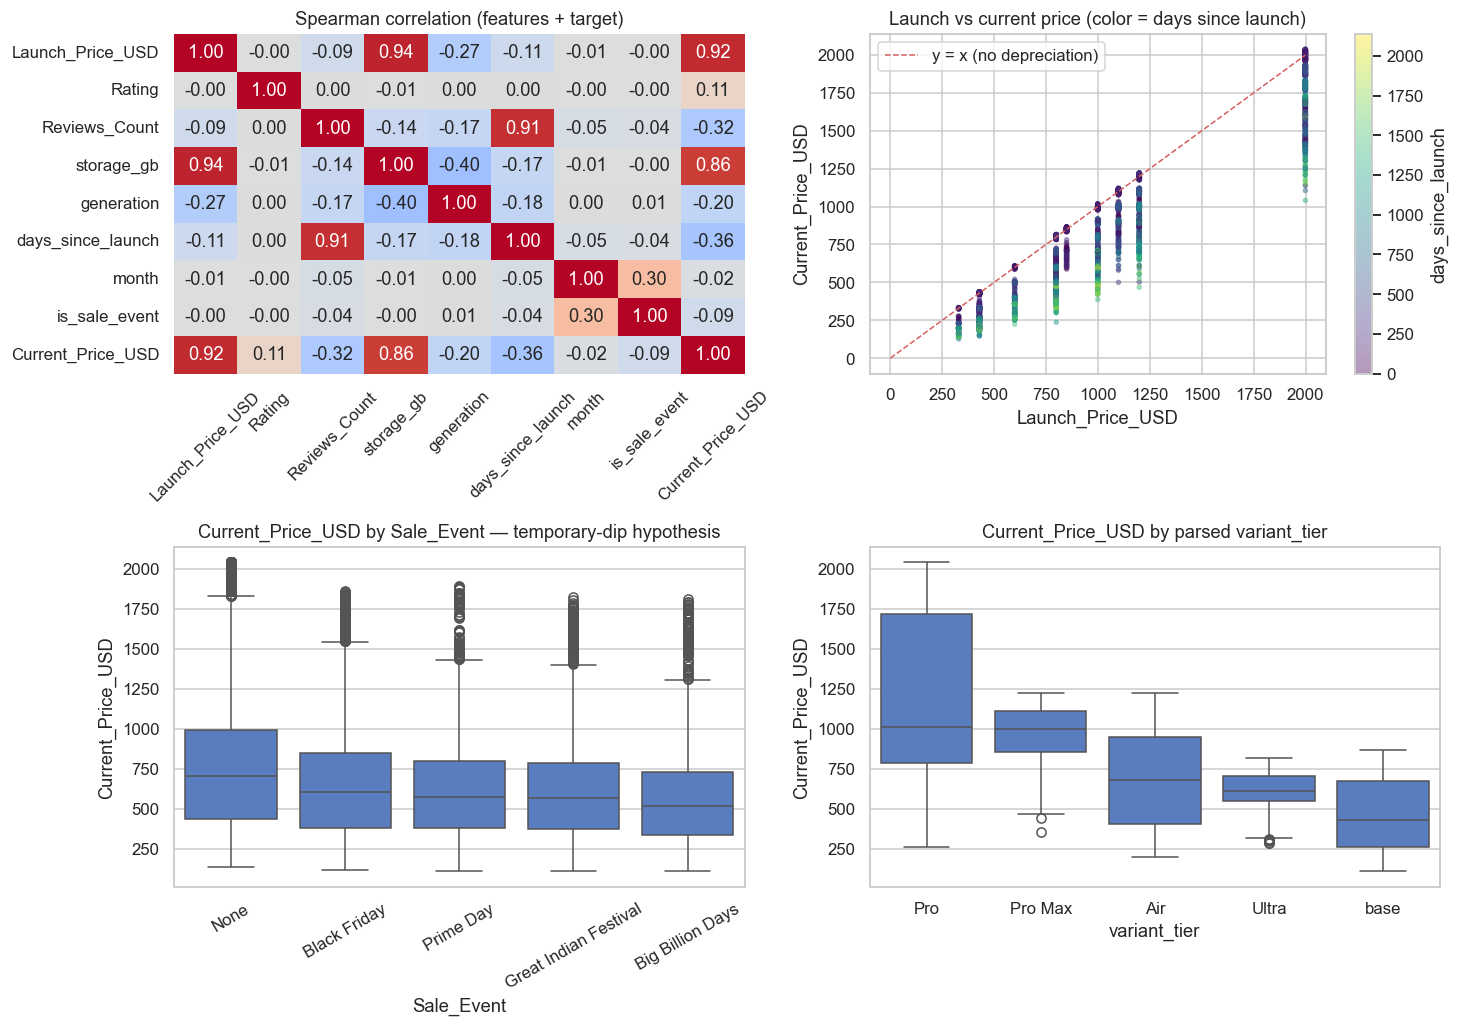

In [ ]:
# 4-Feature-Target Analysis: Feature-Target visualizations and intuition on feature selection

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.5))

corr_cols = NUM_FEATS + [TARGET]
sns.heatmap(df[corr_cols].corr(method='spearman'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[0, 0], cbar=False,
            xticklabels=corr_cols, yticklabels=corr_cols)
axes[0, 0].set_title('Spearman correlation (features + target)')
axes[0, 0].tick_params(axis='x', rotation=45)

sample = df.sample(min(5000, len(df)), random_state=0)
sc = axes[0, 1].scatter(sample['Launch_Price_USD'], sample[TARGET],
                        c=sample['days_since_launch'], cmap='viridis', s=7, alpha=.4)
axes[0, 1].plot([0, sample['Launch_Price_USD'].max()],
                [0, sample['Launch_Price_USD'].max()], 'r--', lw=1, label='y = x (no depreciation)')
axes[0, 1].set(xlabel='Launch_Price_USD', ylabel=TARGET, title='Launch vs current price (color = days since launch)')
axes[0, 1].legend()
plt.colorbar(sc, ax=axes[0, 1], label='days_since_launch')

order = df.groupby('Sale_Event')[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Sale_Event', y=TARGET, order=order, ax=axes[1, 0])
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].set_title(f'{TARGET} by Sale_Event — temporary-dip hypothesis')

sns.boxplot(data=df, x='variant_tier', y=TARGET, ax=axes[1, 1],
            order=df.groupby('variant_tier')[TARGET].median().sort_values(ascending=False).index)
axes[1, 1].set_title(f'{TARGET} by parsed variant_tier')

plt.tight_layout()
plt.show()

# Observation: Launch_Price_USD is the most predictive feature of Current_Price_USD, with a strong positive correlation.
# Launch_Price_USD` dominates `Current_Price_USD` by construction — it sets the scale each product depreciates from — so it stays in the feature set as the anchor 
# while `days_since_launch`, `Condition`, and `Sale_Event` explain the deviation from it. 
# We check the association tables above for the relative ranking of each feature against the raw-price target.


In [ ]:
# 5-Data Test: Temporal patterns & Depreciation over time hypothesis

# Test: does price systematically decrease with time since launch? (ANOVA)
# H0: There is no relationship between time since launch and Apple product price; price does not systematically decrease over time.
# H1: Apple product price decreases as time since launch increases, with additional downward drops occurring around new product release dates.

# Time-bin ANOVA (per category): `days_since_launch` is cut into deciles within each `Product_Category` (binning per category avoids confounding the test with cross-category price-level differences), 
# and a one-way ANOVA tests whether mean `Current_Price_USD` differs across bins. 
# Since ANOVA alone tests *any* difference and not direction, Spearman `rho` between `days_since_launch` and price is reported alongside it to confirm the sign of the effect.

N_BINS = 8
ALPHA = 0.05
df['launch_age_bin'] = df.groupby('Product_Category')['days_since_launch'] \
    .transform(lambda s: pd.qcut(s, q=N_BINS, duplicates='drop'))

# One-way ANOVA on price across days_since_launch bins, per category
rows = []
for cat, g in df.groupby('Product_Category'):
    groups = [grp[TARGET].values for _, grp in g.groupby('launch_age_bin', observed=True)]
    f_stat, p_val = stats.f_oneway(*groups)
    rho, _ = stats.spearmanr(g['days_since_launch'], g[TARGET])
    rows.append({'Product_Category': cat, 'F': f_stat, 'p_value': p_val, 'spearman_rho': rho})
test1 = pd.DataFrame(rows).set_index('Product_Category')

print("Price across days_since_launch bins (per category):")
print(test1.round(4).to_string())

df = df.drop(columns=['launch_age_bin'])

# Verdict
test1_reject = (test1['p_value'] < ALPHA).all()
test1_decreasing = (test1['spearman_rho'] < 0).all()
print(f"\nVERDICT:")
if test1_reject and test1_decreasing:
    print(f"- Rejects H0 in every category (all p < {ALPHA}), and Spearman rho is negative")
    print(f"  in every category -> price decreases systematically with days_since_launch.")
    print(f"  Supports H1's main clause: reject H0.")
else:
    print(f"- {'Rejects' if test1_reject else 'Fails to reject'} H0 across categories; ")
    print(f"  direction is {'consistently negative' if test1_decreasing else 'not consistent across categories'} — see test1 table.")

Price across days_since_launch bins (per category):
                          F  p_value  spearman_rho
Product_Category                                  
Mac                444.1466      0.0       -0.4123
Watch              601.2016      0.0       -0.5206
iPad               747.3696      0.0       -0.5028
iPhone            1729.5862      0.0       -0.5138

VERDICT:
- Rejects H0 in every category (all p < 0.05), and Spearman rho is negative
  in every category -> price decreases systematically with days_since_launch.
  Supports H1's main clause: reject H0.


                                  n_obs  spearman_time  pct_non_decreasing
Model_Name                                                                
Apple Watch Series 6 (44mm)        2572          0.867               0.504
Apple Watch Series 7 (45mm)        2600          0.868               0.506
Apple Watch Series 8 (45mm)        2606          0.865               0.502
Apple Watch Series 9 (45mm)        2530          0.864               0.499
Apple Watch Series X (45mm)        2520          0.856               0.498
Apple Watch Ultra                  2544          0.862               0.505
Apple Watch Ultra 2                2493          0.855               0.506
MacBook Air M1 256GB               2550          0.851               0.505
MacBook Air M2 256GB               2610          0.851               0.507
MacBook Air M3 256GB               2589          0.847               0.491
MacBook Pro 14-inch M1 Pro 512GB   2545          0.858               0.499
MacBook Pro 14-inch M2 Pr

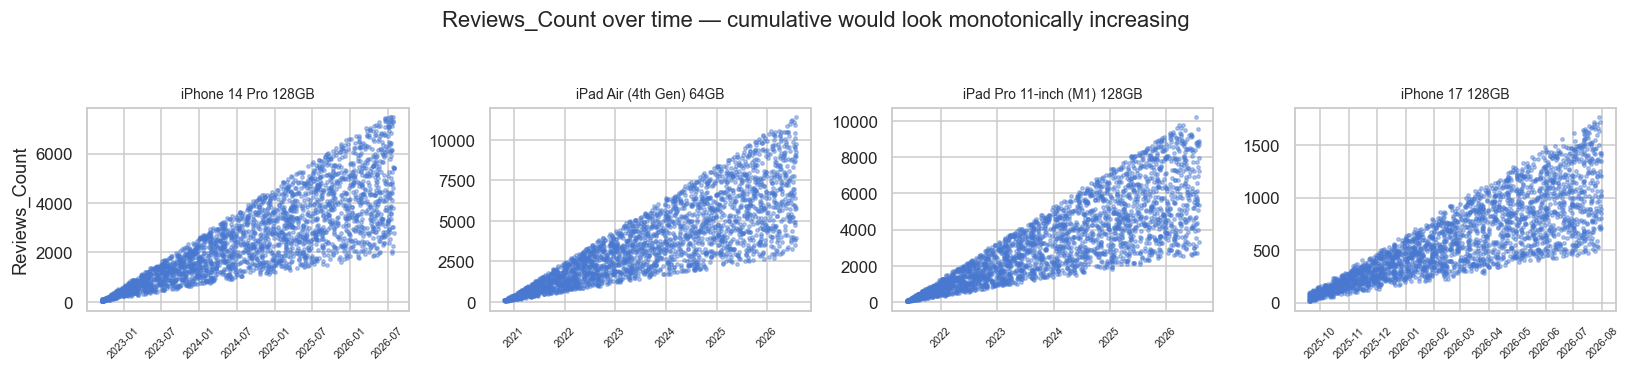

In [21]:
# 5-Data Test: is Reviews_Count cummulative?

# This dataset is synthetically generated, so properties a real marketplace would guarantee must be verified, not assumed. 
# If `Reviews_Count` were real, the same `Model_Name` should accumulate reviews monotonically over time. 
# The check below computes, per model, (a) the Spearman correlation between listing date and `Reviews_Count`, 
# and (b) the fraction of consecutive (date-sorted) observations where the count does not decrease.

srt = df.sort_values('Date')
per_model = srt.groupby('Model_Name').agg(
    n_obs=('Reviews_Count', 'size'),
    spearman_time=('Reviews_Count', lambda s: s.reset_index(drop=True).corr(
        pd.Series(np.arange(len(s))), method='spearman')),
)
per_model['pct_non_decreasing'] = srt.groupby('Model_Name')['Reviews_Count'] \
    .apply(lambda s: s.diff().dropna().ge(0).mean())

print(per_model.round(3).to_string())
med_rho = per_model['spearman_time'].median()
med_mono = per_model['pct_non_decreasing'].median()
print(f"\nMedian Spearman(time, reviews) across models: {med_rho:.3f}")
print(f"Median share of non-decreasing consecutive steps: {med_mono:.3f}")

if med_rho > 0.8 and med_mono > 0.9:
    print("\nVERDICT: Reviews_Count behaves cumulatively -> it is largely a proxy for product age.")
    print("Expect strong collinearity with days_since_launch; keep only one of the two.")
else:
    print("\nVERDICT: Reviews_Count is NOT cumulative — counts fluctuate per listing snapshot.")
    print("The synthetic generator drew them (near-)randomly. It is at best a noisy popularity")
    print("proxy and at worst pure noise: expect weak association with the target (Section 4")
    print("table) and treat it as a drop candidate.")

# Visual: reviews over time for the 4 most-observed models
top4 = df['Model_Name'].value_counts().head(4).index
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=False)
for ax, m in zip(axes, top4):
    g = srt[srt['Model_Name'] == m]
    ax.scatter(g['Date'], g['Reviews_Count'], s=5, alpha=.4)
    ax.set_title(m, fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
axes[0].set_ylabel('Reviews_Count')
fig.suptitle('Reviews_Count over time — cumulative would look monotonically increasing', y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
# 6-Feature Selection: Final Data Quality Flags

flags = []

# Leakage columns: already dropped at load (Section 0) — recorded here for completeness
for c in ['Current_Price_INR (target in INR)', 'Discount_Pct (derived from target)',
          'Launch_Price_INR (redundant with USD)']:
    flags.append((f'Leakage/redundancy: {c.split(" (")[0]}', c.split('(')[1].rstrip(')'),
                  'DROPPED at load — see Section 0'))

# Duplicates
exact = df.duplicated().sum()
flags.append(('Exact duplicate rows', f"{exact:,}",
              'drop before training' if exact else 'none — OK'))
key = df.duplicated(subset=['Date', 'Platform', 'Model_Name', 'Condition']).sum()
flags.append(('Duplicate (Date, Platform, Model, Condition) keys', f"{key:,}",
              'repeated observations per key — use time-based or grouped CV splits'))

# Highly correlated feature pairs (|rho| > 0.9)
feat_corr = df[NUM_FEATS].corr(method='spearman').abs()
upper = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
found = False
for a in upper.columns:
    for b, v in upper[a].dropna().items():
        if v > 0.9:
            flags.append((f'Correlated pair: {b} ~ {a}', f"|rho| = {v:.3f}", 'keep only one'))
            found = True
if not found:
    flags.append(('Highly correlated feature pairs (|rho| > 0.9)', 'none found', 'OK'))

# Near-zero variance
for col in df.columns:
    top_share = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if df[col].nunique(dropna=False) <= 1 or top_share > 0.99:
        flags.append((f'Near-zero variance: {col}', f"top value covers {top_share*100:.1f}%", 'no signal — drop'))

# Transformation needs (continuous columns only)
for col in ['Launch_Price_USD', 'Reviews_Count', 'storage_gb', 'days_since_launch', TARGET]:
    sk = df[col].skew()
    if abs(sk) > 1:
        flags.append((f'Skewed column: {col}', f"skew = {sk:.2f}",
                      'consider log / rank transform for linear models'))

flags_df = pd.DataFrame(flags, columns=['Issue', 'Evidence', 'Implication'])
flags_df

,Issue,Evidence,Implication
0,Leakage/redundancy: Current_Price_INR,target in INR,DROPPED at load — see Section 0
1,Leakage/redundancy: Discount_Pct,derived from target,DROPPED at load — see Section 0
2,Leakage/redundancy: Launch_Price_INR,redundant with USD,DROPPED at load — see Section 0
3,Exact duplicate rows,0,none — OK
4,"Duplicate (Date, Platform, Model, Condition) keys","21,389",repeated observations per key — use time-based or grouped CV splits
5,Correlated pair: Launch_Price_USD ~ storage_gb,|rho| = 0.944,keep only one
6,Correlated pair: Reviews_Count ~ days_since_launch,|rho| = 0.908,keep only one
7,Skewed column: Launch_Price_USD,skew = 1.03,consider log / rank transform for linear models
8,Skewed column: Reviews_Count,skew = 1.25,consider log / rank transform for linear models
9,Skewed column: Current_Price_USD,skew = 1.11,consider log / rank transform for linear models


### 6-Feature Selection: Final Feature Set

### Feature-selection summary for price modeling

**Target:** `Current_Price_USD` — predicted directly as the suggested fair-market listing price.

**Dropped at load (leakage / redundancy):** `Current_Price_INR`, `Discount_Pct`, `Launch_Price_INR` — see Section 0 note.

**Launch date:** `researched_launch_date` (manually sourced per `Model_Name`) matches `proxy_launch_date` (first listing date) closely for every model in this dataset — max 1-day gap, see the Section 1 comparison — so `days_since_launch` is a reliable depreciation clock either way.

**Model_Name-agnostic feature set (deployable on any product a seller lists, including unseen models like iPhone 19 128GB):**

| Feature | Role |
|---|---|
| `Launch_Price_USD` | anchor — sets the scale `Current_Price_USD` depreciates from |
| `days_since_launch` | depreciation clock — core hypothesis driver |
| `Product_Category` | category-specific decay curves |
| `variant_tier`, `storage_gb`, `generation` | parsed from Model_Name — recover its signal without its cardinality |
| `Condition` | stable multiplier hypothesis |
| `Sale_Event` / `is_sale_event`, `month` | temporary festival dips, seasonality |
| `Platform`, `Stock_Status` | marketplace effects (check Section 4 tables for actual signal) |

**Do not one-hot `Model_Name` itself** — unseen models would have no representation, and within-model constancy of launch price makes it partly redundant.

**`Rating` / `Reviews_Count`:** keep only if Section 4 shows real signal; see the Section 5 cumulative-nature verdict — if non-cumulative (synthetic noise), drop `Reviews_Count`.

**Validation:** time-based splits (train early, test late) — this both respects the repeated-observations structure and directly measures what the feature needs in production: suggesting prices for future dates and newly launched models.

## 7. Train/test split — shared baseline for predictive modeling

**Cutoff:** train on rows before **2025-08-01**, test on rows from that date onward.

**Why a time-based cutoff instead of a random split:**

- **Prevents leakage.** The real task is forecasting a fair listing price *forward* in time — a seller lists a product today and needs today's price, with no access to tomorrow's data. A random split would scatter observations of the same `Model_Name` across train and test at nearby (or even later) dates, letting a model implicitly see future price levels for a model it's being evaluated on. Section 6 already flagged 21,389 duplicate `(Date, Platform, Model_Name, Condition)` keys — a random split would routinely place near-identical repeated observations on both sides. A chronological cutoff eliminates this by construction: every train row strictly precedes every test row.
- **Preserves a workable size ratio.** The cutoff below lands close to a 68/32 train/test split — enough test volume (~26k rows) to evaluate reliably, while keeping ~5 years of history in train so every model's full depreciation curve (early listing through late-life pricing) is represented.

**Baseline artifact:** the split below is saved to `apple_pricing_train.csv` / `apple_pricing_test.csv` (same directory as the source data), built on top of every column engineered in Sections 0–1. 

In [ ]:
# 7-Train/Test Split: Time-based split to avoid leakage = STEP 1 - ML PROCESS

CUTOFF = pd.Timestamp('2025-08-01')

df = df.sort_values('Date').reset_index(drop=True)
train = df[df['Date'] < CUTOFF].copy()
test = df[df['Date'] >= CUTOFF].copy()

assert train['Date'].max() < test['Date'].min(), "Train/test overlap in time — split is not chronological"
assert len(train) + len(test) == len(df), "Split does not cover all rows"

n = len(df)
print(f"Train: {len(train):>7,} rows ({len(train)/n*100:.1f}%)  {train['Date'].min():%Y-%m-%d} to {train['Date'].max():%Y-%m-%d}")
print(f"Test:  {len(test):>7,} rows ({len(test)/n*100:.1f}%)  {test['Date'].min():%Y-%m-%d} to {test['Date'].max():%Y-%m-%d}")

train.to_csv('apple_pricing_train.csv', index=False)
test.to_csv('apple_pricing_test.csv', index=False)
print(f"\nSaved: apple_pricing_train.csv ({len(train):,} rows), apple_pricing_test.csv ({len(test):,} rows)")
print("Load these two files directly for modeling — every teammate then trains/evaluates on the")
print("exact same rows, with the exact same engineered features from Sections 0-1.")

Train:  54,099 rows (67.6%)  2020-09-19 to 2025-07-31
Test:   25,901 rows (32.4%)  2025-08-01 to 2026-07-31

Saved: apple_pricing_train.csv (54,099 rows), apple_pricing_test.csv (25,901 rows)
Load these two files directly for modeling — every teammate then trains/evaluates on the
exact same rows, with the exact same engineered features from Sections 0-1.


In [28]:
# STEP 2 - ML PROCESS: Build the pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

# Selected features from section 6

# Skewed numeric features → log transform then scale
LOG_FEATURES = [
    'Launch_Price_USD',    # right-skewed anchor price
    'days_since_launch',   # right-skewed depreciation clock
    'Reviews_Count',       # right-skewed, noisy popularity proxy
]

# Numeric features → scale only (no log needed)
SCALE_FEATURES = [
    'storage_gb',          # NaN for some models → impute first
    'generation',          # NaN for some models → impute first
    'Rating',              # bounded [1-5], roughly symmetric
    'month',               # cyclical but treated as ordinal here
    'is_sale_event',       # binary flag
]

# Categorical features → encode
CATEGORICAL_FEATURES = [
    'Product_Category',    # strong signal (eta² Section 4)
    'variant_tier',        # Pro/Air/Ultra etc.
    'Condition',           # New/Refurbished — stable multiplier
    'Platform',            # marketplace effects
    'Stock_Status',        # availability signal
    'Sale_Event',          # specific event name (captures more than is_sale_event alone)
]

ALL_FEATURES = LOG_FEATURES + SCALE_FEATURES + CATEGORICAL_FEATURES
TARGET = 'Current_Price_USD'


# Sub-pipelines for numeric and categorical features, then combine into a single preprocessor


# Numeric pipeline: impute nulls (storage_gb, generation have NaN for some models)
# then scale (flagged as skewed in Section 6 — log transform or standard scale)

# Log-skewed numeric pipeline: impute → log(x+1) → standardise
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log',     FunctionTransformer(np.log1p, validate=True)),
    ('scaler',  StandardScaler()),
])

# Regular numeric pipeline: impute → standardise
scale_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Categorical pipeline: impute then encode
# handle_unknown='ignore' ensures unseen categories at test time don't crash the model
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])



# Combined preprocessor: combine everything

preprocessor = ColumnTransformer([
    ('log', log_pipeline,         LOG_FEATURES),
    ('num', scale_pipeline,       SCALE_FEATURES),
    ('cat', categorical_pipeline, CATEGORICAL_FEATURES),
])

In [ ]:
# STEP 2 - ML PROCESS: Apply the pipeline to the training data only to avoid preprocessing leakage

# Define X and y from the train split
FEATURES = ALL_FEATURES
TARGET = 'Current_Price_USD'

X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

# Fit the preprocessor on training data only
preprocessor.fit(X_train)

# Transform both
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)  # uses train-fitted params

print(f"X_train processed shape: {X_train_processed.shape}")
print(f"X_test processed shape: {X_test_processed.shape}")

print(f"\nFeature breakdown:")
print(f"  Log-transformed numeric : {len(LOG_FEATURES)} features → {len(LOG_FEATURES)} columns")
print(f"  Scaled numeric          : {len(SCALE_FEATURES)} features → {len(SCALE_FEATURES)} columns")
n_cat_cols = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(CATEGORICAL_FEATURES)
print(f"  One-hot encoded         : {len(CATEGORICAL_FEATURES)} features → {len(n_cat_cols)} columns")
print(f"  Total output columns    : {X_train_processed.shape[1]}")

# Observations:
# Clean output: 29 features total, sensible breakdown.
# The one-hot encoding expanded 6 categorical features into 21 columns which is expected given the cardinality of our categories (Product_Category, Sale_Event etc.).
# Train/test split is roughly 68/32 which matches best-practices

X_train processed shape: (54099, 29)
X_test processed shape: (25901, 29)

Feature breakdown:
  Log-transformed numeric : 3 features → 3 columns
  Scaled numeric          : 5 features → 5 columns
  One-hot encoded         : 6 features → 21 columns
  Total output columns    : 29


In [ ]:
# STEP 3 - ML PROCESS: Select an appropriate model.

# Our target is Current_Price_USD which is a continuous variable, so we have to use regression models. Options:
# Linear Regression: Finds the best fit line, no constraints
# Ridge/Lasso Regression: Adds regularization to prevent overfitting
# Decision Tree Regression: Splits the data based on feature values
# Random Forest: Ensemble of decision trees
# XGBoost: Gradient boosting implementation
# KNN (sampled): Uses the k-nearest neighbors algorithm

In [33]:
# STEP 3 - ML PROCESS: Model Training
# I will do my Model Training for Linear Regression and its variants (Ridge and Lasso)

# Each model uses TimeSeriesSplit CV to respect temporal structure, rather than K-fold CV which does a random split and we loose the temporal structure we setup
# Grid search finds the best hyperparameters on training data only
# Test data is never touched until Step 5 (evaluation)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error, r2_score

# Cross-validation strategy: TimeSeriesSplit to respect temporal order
cv = TimeSeriesSplit(n_splits=5)

# ── 1. LINEAR REGRESSION ──────────────────────────────────────────────
# No hyperparameters to tune — train directly
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
print("✓ Linear Regression trained")

# ── 2. RIDGE REGRESSION ───────────────────────────────────────────────
# Tune alpha (regularization strength)
ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid={'alpha': [0.01, 0.1, 1, 10, 100, 1000]},
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
ridge_grid.fit(X_train_processed, y_train)
best_ridge = ridge_grid.best_estimator_
print(f"✓ Ridge trained | best alpha: {ridge_grid.best_params_['alpha']}")

# ── 3. LASSO REGRESSION ───────────────────────────────────────────────
# Tune alpha (regularization strength)
# Lasso may zero out some coefficients → automatic feature selection
lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=50000),
    param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
lasso_grid.fit(X_train_processed, y_train)
best_lasso = lasso_grid.best_estimator_
print(f"✓ Lasso trained | best alpha: {lasso_grid.best_params_['alpha']}")



✓ Linear Regression trained
✓ Ridge trained | best alpha: 100
✓ Lasso trained | best alpha: 1


In [ ]:
# STEP 3 - ML PROCESS: Model Training insight
# From the Lasso regression we can see which features were zeroed out and which were kept. 
# This gives us insight into which features are most important for predicting the target variable, Current_Price_USD.

# ── LASSO FEATURE SELECTION INSIGHT ───────────────────────────────────
# Show which features Lasso zeroed out vs kept
feature_names = (
    LOG_FEATURES +
    SCALE_FEATURES +
    list(preprocessor.named_transformers_['cat']['encoder']
         .get_feature_names_out(CATEGORICAL_FEATURES))
)
lasso_coefs = pd.Series(best_lasso.coef_, index=feature_names)
n_zeroed = (lasso_coefs == 0).sum()
print(f"\nLasso feature selection:")
print(f"  Features zeroed out : {n_zeroed} / {len(lasso_coefs)}")
print(f"  Features kept       : {len(lasso_coefs) - n_zeroed} / {len(lasso_coefs)}")
print(f"\nTop 10 most impactful features (by absolute coefficient):")
print(lasso_coefs.abs().sort_values(ascending=False).head(10).round(4))


# Observation: Lasso zeroed out 12 out of 29 features, automatically identifying them as not useful for price prediction.
# The top predictors align with our EDA insights and make intuitive business sense:
# Launch_Price_USD and storage_gb dominate: price is anchored to launch price and storage tier
# Condition_New: new vs refurbished is a major price driver
# variant_tier_Pro Max: premium tier commands a premium price
# days_since_launch: confirms our H1 hypothesis, depreciation is real and measurable
# is_sale_event: sale events meaningfully impact price



Lasso feature selection:
  Features zeroed out : 12 / 29
  Features kept       : 17 / 29

Top 10 most impactful features (by absolute coefficient):
Launch_Price_USD           229.3605
storage_gb                 229.1072
Condition_New              183.2231
variant_tier_Pro Max        50.6975
is_sale_event               37.8426
Product_Category_iPhone     35.8666
days_since_launch           34.4438
Product_Category_Watch      34.1191
generation                  33.3238
variant_tier_Air            30.0810
dtype: float64


In [ ]:
# STEP 3 - ML PROCESS: Model Training insight
# Training performance summary is evaluated on the training set only, to check for overfitting. Test evaluation will happen in Step 5.

# ── QUICK TRAINING PERFORMANCE SUMMARY ────────────────────────────────
# Train scores only — test evaluation happens at Step 5
models = {
    'Linear Regression': lr,
    'Ridge Regression':  best_ridge,
    'Lasso Regression':  best_lasso,
}

print("\nTraining performance (in-sample — for reference only):")
rows = []
for name, model in models.items():
    y_pred_train = model.predict(X_train_processed)
    rmse = root_mean_squared_error(y_train, y_pred_train)
    r2   = r2_score(y_train, y_pred_train)
    rows.append({'Model': name, 'Train RMSE': round(rmse, 2), 'Train R²': round(r2, 4)})
print(pd.DataFrame(rows).set_index('Model').to_string())
print("\nNote: test performance evaluated at Step 5 — do not use test data yet.")


# Observations: All three models have R² ~0.96, meaning they explain 96% of price variance, which is very strong. 
# It is a flag: A R² of 0.96 on training data is very high and could indicate mild overfitting, which is exactly why we need Step 5 test evaluation. 
# If test R² drops significantly (e.g. to 0.85), that's overfitting. If it stays near 0.96, the model genuinely generalizes well.
# RMSE ~90-93 USD means predictions are off by ~$90 on average in training
# Linear and Ridge are nearly identical (expected: Ridge only kicks in when features are highly correlated)
# Lasso is slightly weaker (93 RMSE) because it sacrificed some accuracy for simplicity by zeroing 12 features



Training performance (in-sample — for reference only):
                   Train RMSE  Train R²
Model                                  
Linear Regression       90.35    0.9620
Ridge Regression        90.65    0.9617
Lasso Regression        93.05    0.9597

Note: test performance evaluated at Step 5 — do not use test data yet.


In [ ]:
# STEP 4 - ML PROCESS: Apply the pre-trained pipeline to the testing data

# ── STEP 4: APPLY PIPELINE TO TEST DATA ───────────────────────────────
# preprocessor was fitted on train only — just transform test here
# (already done in Step 2, X_test_processed is ready)

In [38]:
# STEP 5 - ML PROCESS: Evaluate all three models

import matplotlib.gridspec as gridspec
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

models = {
    'Linear Regression': lr,
    'Ridge Regression':  best_ridge,
    'Lasso Regression':  best_lasso,
}

results = []
predictions = {}

for name, model in models.items():
    y_pred_train = model.predict(X_train_processed)
    y_pred_test  = model.predict(X_test_processed)
    predictions[name] = y_pred_test

    results.append({
        'Model'       : name,
        'Train RMSE'  : round(root_mean_squared_error(y_train, y_pred_train), 2),
        'Test RMSE'   : round(root_mean_squared_error(y_test,  y_pred_test),  2),
        'Train R²'    : round(r2_score(y_train, y_pred_train), 4),
        'Test R²'     : round(r2_score(y_test,  y_pred_test),  4),
        'Test MAE'    : round(mean_absolute_error(y_test, y_pred_test), 2),
        'Overfit gap' : round(r2_score(y_train, y_pred_train) -
                              r2_score(y_test,  y_pred_test),  4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print("Model Evaluation — Train vs Test:")
print(results_df.to_string())

Model Evaluation — Train vs Test:
                   Train RMSE  Test RMSE  Train R²  Test R²  Test MAE  Overfit gap
Model                                                                             
Linear Regression       90.35     108.16    0.9620   0.9441     88.94       0.0179
Ridge Regression        90.65     106.29    0.9617   0.9460     85.98       0.0157
Lasso Regression        93.05     106.88    0.9597   0.9454     85.88       0.0142


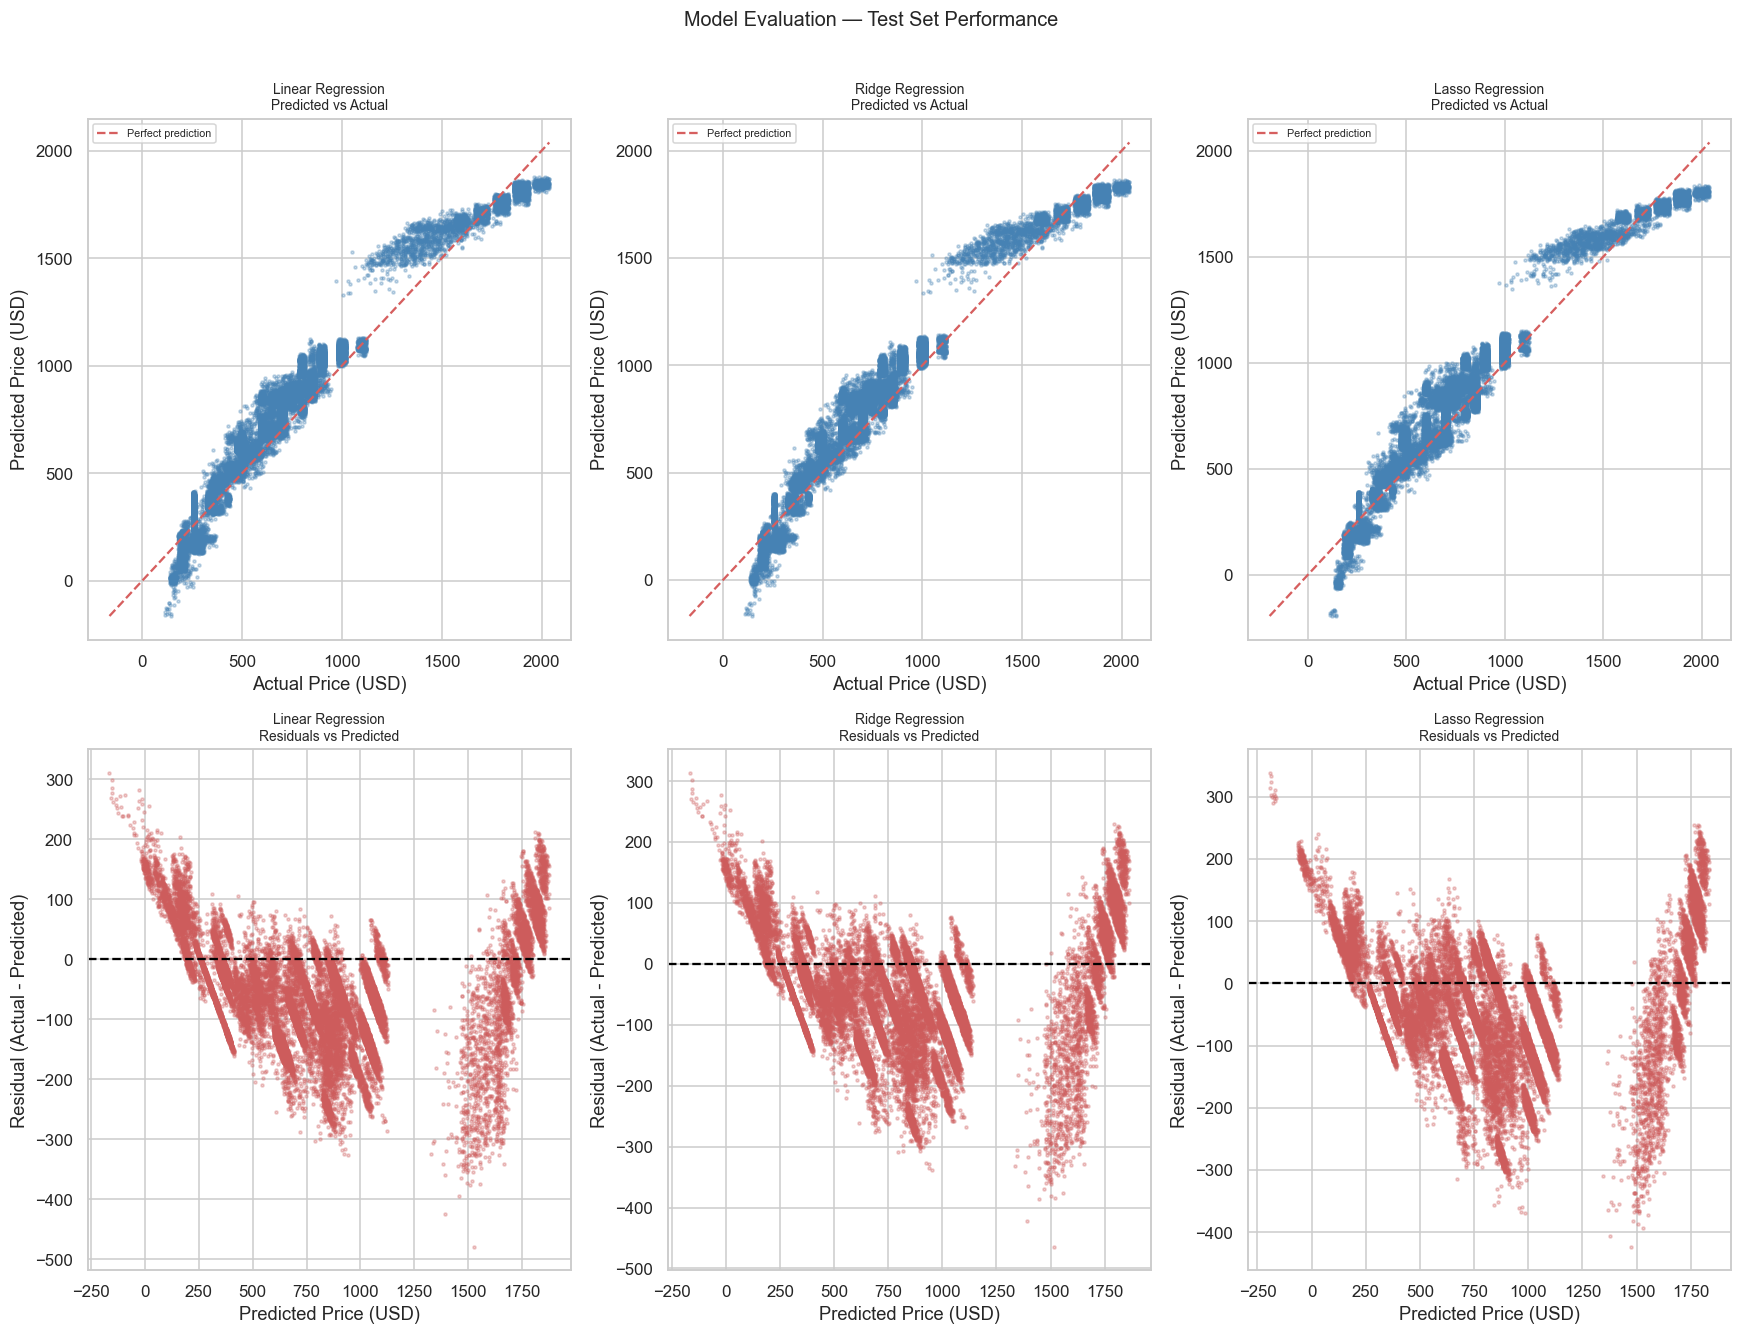

In [ ]:
# STEP 5 - ML PROCESS: Evaluating the models - visualizations

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig)

for i, (name, model) in enumerate(models.items()):
    y_pred = predictions[name]

    # Row 1: Predicted vs Actual
    ax1 = fig.add_subplot(gs[0, i])
    ax1.scatter(y_test, y_pred, s=4, alpha=0.3, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax1.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
    ax1.set_title(f'{name}\nPredicted vs Actual', fontsize=9)
    ax1.set_xlabel('Actual Price (USD)')
    ax1.set_ylabel('Predicted Price (USD)')
    ax1.legend(fontsize=7)

    # Row 2: Residuals
    ax2 = fig.add_subplot(gs[1, i])
    residuals = y_test.values - y_pred
    ax2.scatter(y_pred, residuals, s=4, alpha=0.3, color='indianred')
    ax2.axhline(0, color='black', lw=1.5, linestyle='--')
    ax2.set_title(f'{name}\nResiduals vs Predicted', fontsize=9)
    ax2.set_xlabel('Predicted Price (USD)')
    ax2.set_ylabel('Residual (Actual - Predicted)')

plt.suptitle('Model Evaluation — Test Set Performance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


# Observations:

# Predicted vs. Actual (on all 3 models): All three scatter plots show points hugging the red diagonal line closely, this is what we want.
# A perfect model would have every point on the diagonal. The slight fan shape widening at higher prices (above $1,500) suggests 
# all three models are slightly less accurate for premium products, which makes intuitive sense since there are fewer high-end observations to learn from.

# Residuals (on all 3 models): The vertical stripe pattern is the key finding here. 
# Residuals should ideally be randomly scattered around zero, yet instead we see clear diagonal bands.
# This tells us something important: all 3 models are making systematic errors for specific products.
# The stripes correspond to discrete product lines (iPhone 15, MacBook Pro 14-inch etc.),
# each product has a fixed launch price, so predictions cluster at specific price points.
# This is a known limitation of linear models on this dataset, they can't fully capture the discrete, product-specific pricing structure. 
# We will have to compare how the other non-linear models (Random Forest and XGBoost?) handle this.

In [ ]:
# STEP 5 - ML PROCESS: Evaluating the models - overfit check

print("\nOverfit check (Train R² - Test R²):")
print("< 0.02 → negligible | 0.02-0.05 → mild | > 0.05 → concerning")
for _, row in results_df.iterrows():
    gap = row['Overfit gap']
    flag = '✓ negligible' if gap < 0.02 else ('⚠ mild' if gap < 0.05 else '✗ concerning')
    print(f"  {_:<20} gap = {gap:.4f} → {flag}")


# Observation: Overall: all three models generalize well, there is no overfitting concern.
# The overfit gaps are all negligible (< 0.02), meaning the 3 models learned real patterns from the data, not noise. 
# The temporal train/test split was the right call.

# Some takeaways for group report comparison:
# Ridge slightly outperforms Linear, regularization helped marginally, suggesting mild multicollinearity in the features.
# Lasso trades accuracy for simplicity, slightly higher RMSE but automatically identified 12 irrelevant features, which is valuable for interpretability.
# All three miss non-linear patterns, the stripe residuals suggest tree-based models may outperform significantly.
# days_since_launch is a significant predictor, confirming your H1 hypothesis even within linear models



Overfit check (Train R² - Test R²):
< 0.02 → negligible | 0.02-0.05 → mild | > 0.05 → concerning
  Linear Regression    gap = 0.0179 → ✓ negligible
  Ridge Regression     gap = 0.0157 → ✓ negligible
  Lasso Regression     gap = 0.0142 → ✓ negligible


In [42]:
# Observation and questions I had about the diagonals: 
# We are predicting Current_Price, and one of the original variables is Launch_Price. 
# What if the residual diagonals we are seeing are a sign that the model actual performs much worse than we think?
# Ex: What if 80% of the "current price" data is still set at the launch price data (because little time has passed)? 
# In that case our model would offer prices close to launch price then could be completely wrong the rest of the time. 
# My question: can we evaluate what exactly it is predicting, and how good it is at predicting current prices that do have an interesting variation to show from launch price?
# Because as a reseller, if my model is bad, i might as well just set the price at launch price -10$ and not go through the whole process of modelling with AI.


# In cleaner terms: the residual stripe pattern may suggest that model performance is overstated.
# The residual plots reveal a structured diagonal stripe pattern rather than the random scatter expected from a well-specified model. 
# This pattern is a diagnostic signal worth investigating before concluding the models perform well.
# What the stripe pattern specifically suggests: the diagonal bands correspond to discrete product lines, each anchored at a fixed launch price point. 
# The model captures the level (launch price tier) well but may be systematically failing to capture the variation within each product's depreciation curve, 
# precisely where the business value of the model lies.


Price vs Launch Price breakdown:
  At launch price (within $1): 1.4%
  Above launch price (>$1):    10.4%
  Below launch price (<-$1):   88.2%

Price change distribution:
count    80000.00
mean       -21.42
std         16.70
min        -73.13
25%        -36.79
50%        -21.31
75%         -6.67
max          2.00
Name: pct_change_from_launch, dtype: float64


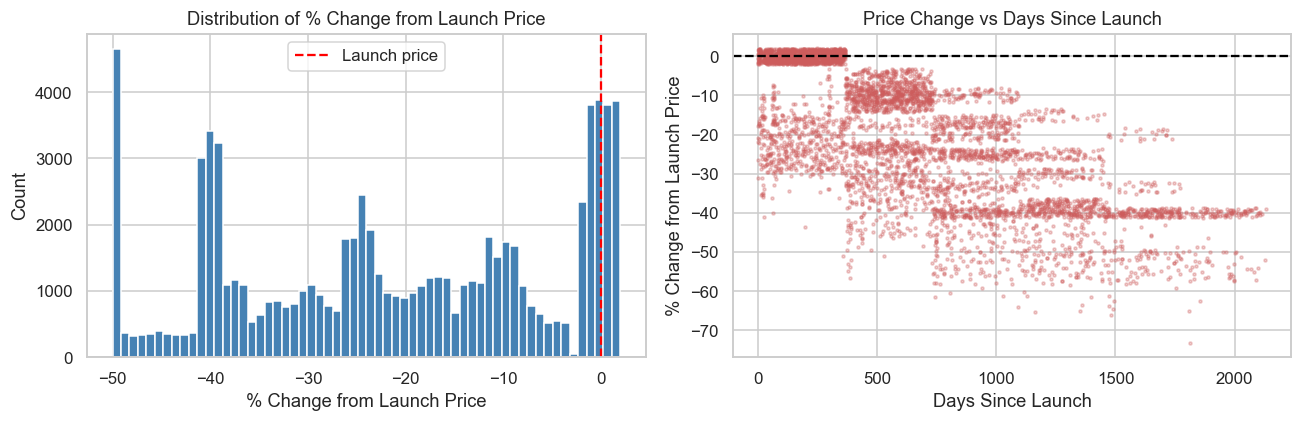

In [ ]:
# STEP 5 - ML PROCESS: Evaluating the models - diagnostic 

# To validate this concern, we segment the test set into:
# At-launch rows: Current_Price_USD ≈ Launch_Price_USD (within $1 tolerance)
#Depreciated rows: Current_Price_USD has meaningfully moved from Launch_Price_USD
# And evaluate model performance separately on each segment.
#  A model with genuine predictive power should perform well on the depreciated segment. If it does not, the high overall R² is misleading.

# ── DIAGNOSE: How much of Current_Price_USD == Launch_Price_USD? ───────

# Check price variation relative to launch price
df['price_vs_launch'] = df['Current_Price_USD'] - df['Launch_Price_USD']
df['pct_change_from_launch'] = (df['price_vs_launch'] / df['Launch_Price_USD']) * 100

# How many rows are AT launch price (within $1 tolerance)?
at_launch = (df['price_vs_launch'].abs() <= 1).mean() * 100
above_launch = (df['price_vs_launch'] > 1).mean() * 100
below_launch = (df['price_vs_launch'] < -1).mean() * 100

print(f"Price vs Launch Price breakdown:")
print(f"  At launch price (within $1): {at_launch:.1f}%")
print(f"  Above launch price (>$1):    {above_launch:.1f}%")
print(f"  Below launch price (<-$1):   {below_launch:.1f}%")

print(f"\nPrice change distribution:")
print(df['pct_change_from_launch'].describe().round(2))

# Distribution of price changes
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['pct_change_from_launch'].clip(-50, 50).hist(bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='Launch price')
plt.title('Distribution of % Change from Launch Price')
plt.xlabel('% Change from Launch Price')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
# Scatter: days since launch vs price change
sample = df.sample(min(5000, len(df)), random_state=42)
plt.scatter(sample['days_since_launch'], sample['pct_change_from_launch'], 
            s=4, alpha=0.3, color='indianred')
plt.axhline(0, color='black', linestyle='--')
plt.title('Price Change vs Days Since Launch')
plt.xlabel('Days Since Launch')
plt.ylabel('% Change from Launch Price')

plt.tight_layout()
plt.show()


# Observation: good news, it flips the concern.
# 88.2% of prices are BELOW launch price, meaning the dataset is overwhelmingly showing real depreciation, not prices stuck at launch.
# Only 1.4% are at launch price. Our models aren't learning a trivial "output launch price" pattern.

# Observation on the price distribution, new insights:
# Mean: -21.4% below launch price
# Median: -21.3% very symmetric, meaning depreciation is consistent
# Range: up to -73% below launch price at the most discounted end
# Max: only +2% above launch; almost no scarcity premiums

# Conclusions on the stripes: The stripes aren't from prices being stuck at launch, they're from something different: discrete product clustering. 
# Each of the 31 product models has a fixed launch price (e.g. iPhone 15 always launched at $799).
# When the model predicts, it groups predictions around those anchor points, creating vertical bands at $299, $399, $799, $999, $1,299 etc. 
# This is a structural feature of the data, not a model failure.